In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

PURPLE_MAIN = "#caa5f1"
PURPLE_LIGHT = "#E9E0FF"

PURPLE_PALETTE = [
    "#E9E0FF",  
    "#E1D3FB",
    "#D7BFF6",
    "#D0B1F4",
    "#caa5f1"
]

DATA_PATH = Path("/Users/federico/Desktop/progetto VIS/4.3 neurologia/06_stroke_data.csv")
df = pd.read_csv(DATA_PATH)

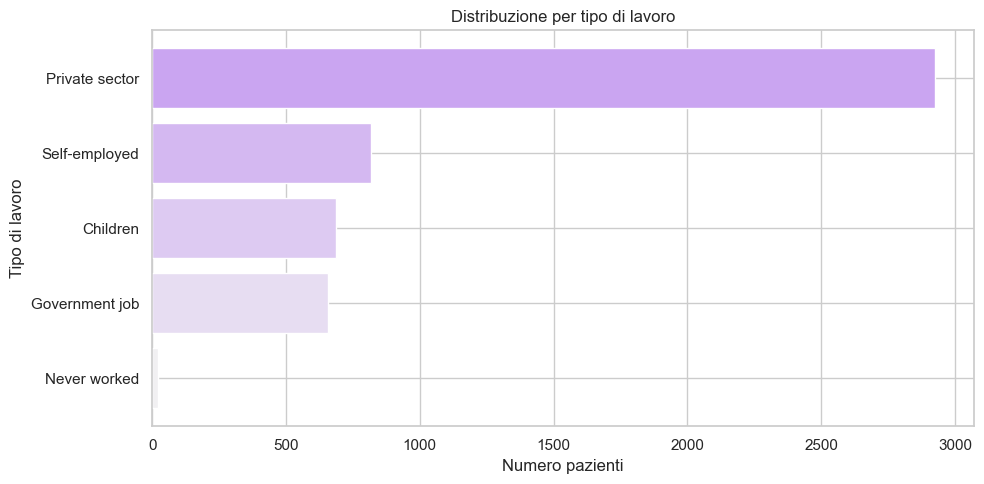

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

work_labels = {
    "Private": "Private sector",
    "Self-employed": "Self-employed",
    "Govt_job": "Government job",
    "children": "Children",
    "Never_worked": "Never worked"
}
work_counts = df["work_type"].map(work_labels).value_counts().sort_values()

purple_grad = sns.light_palette(PURPLE_MAIN, n_colors=len(work_counts), reverse=False)
ax.barh(work_counts.index, work_counts.values, color=purple_grad)
ax.set_xlabel("Numero pazienti")
ax.set_ylabel("Tipo di lavoro")
ax.set_title("Distribuzione per tipo di lavoro")

plt.tight_layout()
plt.show()

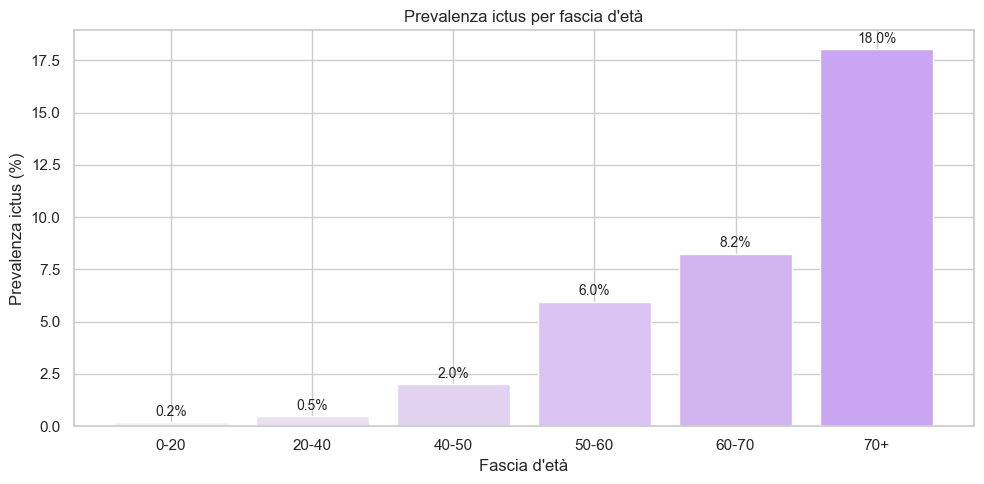

In [7]:
df["age_group"] = pd.cut(df["age"], bins=[0, 20, 40, 50, 60, 70, 100], 
                          labels=["0-20", "20-40", "40-50", "50-60", "60-70", "70+"])

prevalence = df.groupby("age_group", observed=True)["stroke"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
purple_grad = sns.light_palette(PURPLE_MAIN, n_colors=len(prevalence), reverse=False)
bars = ax.bar(prevalence.index, prevalence.values, color=purple_grad)
ax.set_xlabel("Fascia d'età")
ax.set_ylabel("Prevalenza ictus (%)")
ax.set_title("Prevalenza ictus per fascia d'età")

for bar, val in zip(bars, prevalence.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

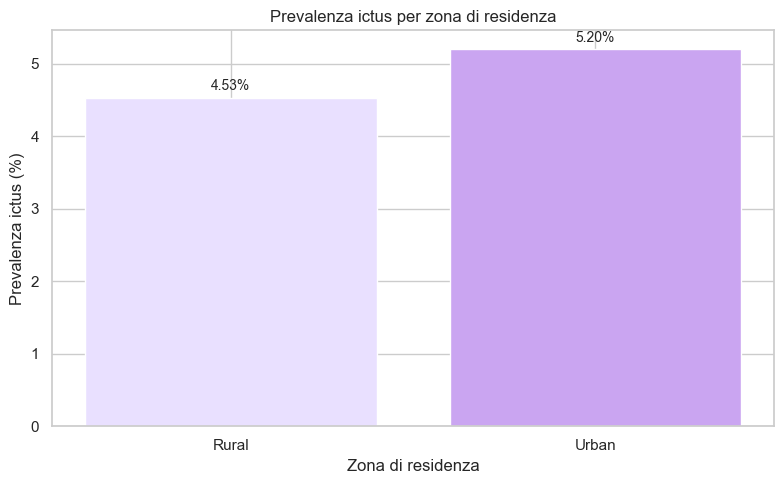

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

prevalence_residence = df.groupby("Residence_type")["stroke"].mean() * 100
bars = ax.bar(prevalence_residence.index, prevalence_residence.values, color=[PURPLE_LIGHT, PURPLE_MAIN])
ax.set_xlabel("Zona di residenza")
ax.set_ylabel("Prevalenza ictus (%)")
ax.set_title("Prevalenza ictus per zona di residenza")
for bar, val in zip(bars, prevalence_residence.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{val:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()